1. Setup

In [2]:
import sys  #Tương tác với trình biên dịch python
sys.path.append("..")  # thêm đường dẫn python có thể để import được từ src/ (Thư mục khác cha với load_imdb_data) 
# ".." tức là lùi lên một cấp -> cấp cha

from src.load_data import load_imdb_data
import pandas as pd
import matplotlib.pyplot as plt     #Biểu đồ 
from collections import Counter     #Dùng để đếm list -> return bảng băm
import re   #thư viện xử lí chuỗi
import os   #Thư viện để tương tác với OS

os.makedirs("../reports", exist_ok=True)        #Tạo thư mục reports

df = load_imdb_data("../data/raw/IMDB Dataset.csv")
print(df.shape)
df.head()

[INFO] Phát hiện 418 review trùng lặp - sẽ loại bỏ.
(49582, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


2. Class balance

sentiment
positive    24884
negative    24698
Name: count, dtype: int64
sentiment
positive    50.19
negative    49.81
Name: proportion, dtype: float64


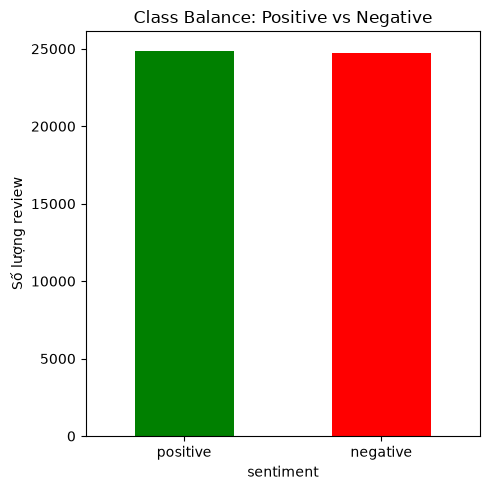

In [10]:
counts = df["sentiment"].value_counts()     #Đếm tần suất positive và negative
pct = df["sentiment"].value_counts(normalize=True) * 100        #Lấy tỉ lệ của mỗi positive và negative trong toàn bộ, *100 để về %

print(counts)
print(pct.round(2))

plt.figure(figsize=(5, 5))      #tạo canvas mới
counts.plot(kind="bar", color=["green", "red"])   #plot() có sẵn trong pandas, "bar" = vẽ biểu đồ cột
plt.title("Class Balance: Positive vs Negative")
plt.ylabel("Số lượng review")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/class_balance.png")     #Lưu vào report
plt.show()

Chốt số liệu:
-   positive: 24884 (50.19%); negative: 24698 (49.81%)
-> Cân bằng (~50/50) nên ta chọn metric chính là Accuracy


3. Phân phối độ dài review

count    49582.000000
mean       231.350167
std        171.542020
min          4.000000
25%        126.000000
50%        173.000000
75%        281.000000
max       2470.000000
Name: word_count, dtype: float64


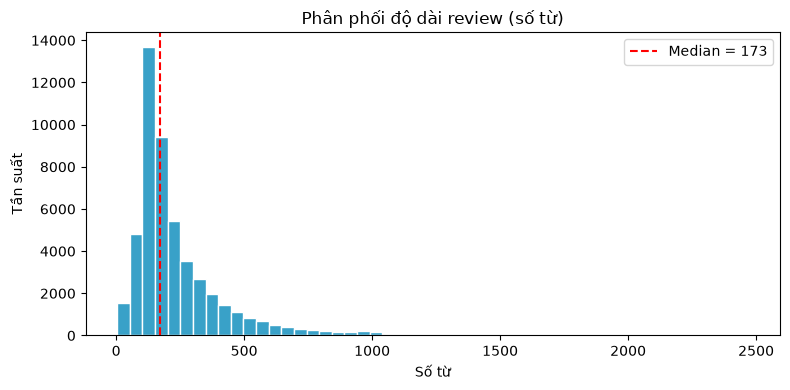

In [ ]:
df["word_count"] = df["review"].str.split().str.len()

print(df["word_count"].describe())      #Mô tả tổng quát về độ dài các reviews

plt.figure(figsize=(8, 4))
plt.hist(df["word_count"], bins=50, color="#39A1C8", edgecolor="white")     #Tạo biểu số tần số histogram
plt.axvline(df["word_count"].median(), color="red", linestyle="--",
            label=f'Median = {df["word_count"].median():.0f}')      #Nhãn hiển thị trên góc cho đường median
plt.title("Phân phối độ dài review (số từ)")
plt.xlabel("Số từ")
plt.ylabel("Tần suất")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/length_distribution.png")
plt.show()

```
min: 4
median: 173
max: 2470
=> Nhận xét:
    + Review khá dài so với dòng nhận xét bình thường -> có thể kho vocab sẽ rất lớn theo
    + Ước lượng: Chọn max_features khoảng 5000 ~ 20000 (Tức là chỉ dùng tối đa bấy nhiêu từ để train, những từ hiếm gặp hơn bỏ qua) -> dim(vector đại diện) = đúng bấy nhiêu, nếu một review có từ không thuộc đống này, -> tự cho giá trị chiều đó = 0.
    + Ước lượng là để tham khảo, con số cụ thể sẽ chốt sau preprocess
```

5. Phát hiện rác trong text

In [ ]:
n_html = df["review"].str.contains(r"<.*?>", regex=True).sum()      #chữ r là để coi bên trong "" là string thuần, ko bị \ ngắt
n_br = df["review"].str.contains(r"<br\s*/?>", regex=True, flags=re.IGNORECASE).sum()   #Regex là để tìm những đoạn review có chứa đống này
n_entity = df["review"].str.contains(r"&\w+;", regex=True).sum()    #cái flags là để bỏ qua phân biệt chữ hoa/thường

print(f"Review chứa HTML tag bất kỳ : {n_html} ({n_html/len(df)*100:.1f}%)")
print(f"Review chứa riêng <br />    : {n_br} ({n_br/len(df)*100:.1f}%)")
print(f"Review chứa HTML entity     : {n_entity} ({n_entity/len(df)*100:.1f}%)")

# Liệt kê cụ thể các loại tag khác ngoài <br />, để không bỏ sót rác
all_tags = df["review"].str.findall(r"<[^>]+>")
tag_counter = Counter(tag.lower() for tags in all_tags for tag in tags)
print("Top 10 tag phổ biến nhất:")
for tag, cnt in tag_counter.most_common(10):
    print(f"  {tag}: {cnt}")

# Xem mẫu thực tế
for text in df["review"].sample(5, random_state=42):
    print(text[:200])
    print("---")

Review chứa HTML tag bất kỳ : 28968 (58.4%)
Review chứa riêng <br />    : 28966 (58.4%)
Review chứa HTML entity     : 4 (0.0%)
Top 10 tag phổ biến nhất:
  <br />: 200409
  <i>: 8
  </i>: 8
  <grin>: 2
  <=8.<br />: 2
  < cough >: 2
  <p>: 1
  < yes >: 1
  <3 <br />: 1
  <<<<<br />: 1
"Soul Plane" is a horrible attempt at comedy that only should appeal people with thick skulls, bloodshot eyes and furry pawns. <br /><br />The plot is not only incoherent but also non-existent, acting
---
Guest from the Future tells a fascinating story of time travel, friendship, battle of good and evil -- all with a small budget, child actors, and few special effects. Something for Spielberg and Lucas
---
"National Treasure" (2004) is a thoroughly misguided hodge-podge of plot entanglements that borrow from nearly every cloak and dagger government conspiracy cliché that has ever been written. The film 
---
OK. First said, I just wanted to check whether this movie has an average rating below or exactly -1.

```
Review chứa HTML tag bất kỳ : 28968 (58.4%)
Review chứa riêng <br />    : 28966 (58.4%)
Review chứa HTML entity     : 4 (0.0%)
Top 10 tag phổ biến nhất:
  <br />: 200409
  <i>: 8
  </i>: 8
  <grin>: 2
  <=8.<br />: 2
  < cough >: 2
  <p>: 1
  < yes >: 1
  <3 <br />: 1
  <<<<<br />: 1
```

6. Wordcloud/tần suất từ theo lớp

Top 20 từ - positive: [('the', 325111), ('and', 170782), ('a', 160440), ('of', 150236), ('to', 129177), ('is', 108654), ('in', 95343), ('i', 66516), ('it', 64530), ('this', 63902), ('that', 63643), ('as', 49184), ('/><br', 48800), ('with', 44273), ('for', 42681), ('was', 42145), ('but', 37886), ('his', 33237), ('on', 31337), ('film', 29275)]
Top 20 từ - negative: [('the', 308870), ('a', 153968), ('and', 140596), ('of', 134372), ('to', 133422), ('is', 94834), ('in', 83144), ('i', 73877), ('this', 73496), ('that', 65536), ('it', 64125), ('/><br', 51411), ('was', 50349), ('for', 41199), ('with', 39677), ('but', 39384), ('as', 38408), ('movie', 34459), ('on', 31067), ('have', 29915)]


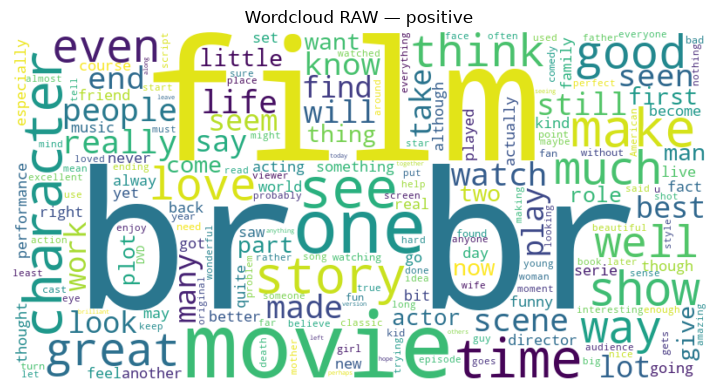

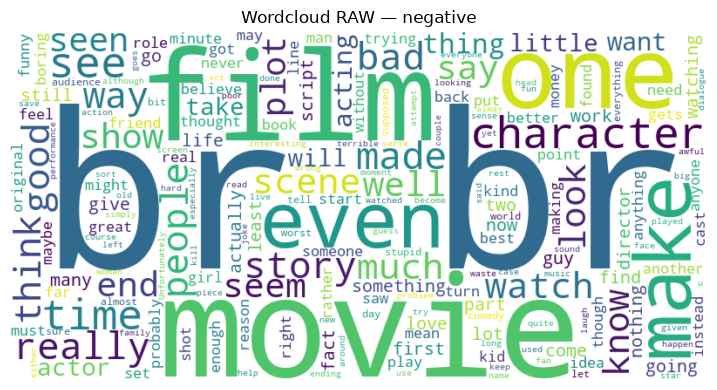

In [26]:
from wordcloud import WordCloud

def get_top_words(texts, n=20):
    words = " ".join(texts).lower().split()
    return Counter(words).most_common(n)

pos_words = get_top_words(df[df["sentiment"] == "positive"]["review"])
neg_words = get_top_words(df[df["sentiment"] == "negative"]["review"])

print("Top 20 từ - positive:", pos_words)
print("Top 20 từ - negative:", neg_words)

for label in ["positive", "negative"]:
    text_blob = " ".join(df[df["sentiment"] == label]["review"])
    wc = WordCloud(width=800, height=400, background_color="white").generate(text_blob)
    plt.figure(figsize=(8, 4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Wordcloud RAW — {label}")
    plt.tight_layout()
    plt.savefig(f"../reports/wordcloud_{label}_raw.png")
    plt.show()

```
Top 20 từ - positive: [('the', 325111), ('and', 170782), ('a', 160440), ('of', 150236), ('to', 129177), ('is', 108654), ('in', 95343), ('i', 66516), ('it', 64530), ('this', 63902), ('that', 63643), ('as', 49184), ('/><br', 48800), ('with', 44273), ('for', 42681), ('was', 42145), ('but', 37886), ('his', 33237), ('on', 31337), ('film', 29275)]
Top 20 từ - negative: [('the', 308870), ('a', 153968), ('and', 140596), ('of', 134372), ('to', 133422), ('is', 94834), ('in', 83144), ('i', 73877), ('this', 73496), ('that', 65536), ('it', 64125), ('/><br', 51411), ('was', 50349), ('for', 41199), ('with', 39677), ('but', 39384), ('as', 38408), ('movie', 34459), ('on', 31067), ('have', 29915)]

Do cơ chế stopwword nên một số từ không xuất hiện trong wordcloud

-> Sẽ cần xóa các stopword + đống thẻ HTML để bớt rác dữ liệu
```